# Cricket Player Performance 

## 1. Import Tools

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

%matplotlib inline
pd.set_option('display.max_columns', None)

## 2. Import Data

In [4]:
df = pd.read_csv(r'Data\cricket_player_ performance.csv')
df

,Date,Player_Name,Team,Opponent,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Match_Result,Match_Type,Player_Impact_Score,Strike_Rate,Catches,Target_Score
0,2024-06-07,Jos Buttler,New Zealand,Bangladesh,76,60,19,5,5,3.11,Loss,ODI,184.78,126.67,3,305
1,2020-06-21,Rohit Sharma,Australia,India,146,73,1,10,4,6.56,Loss,T20,171.88,200.00,1,135
2,2024-02-05,Joe Root,England,Bangladesh,116,41,15,15,5,6.42,Loss,T20,220.16,282.93,4,327
3,2022-01-28,Steve Smith,Sri Lanka,Australia,147,99,12,11,0,4.78,Win,T20,120.94,148.48,0,287
4,2023-06-12,Joe Root,Sri Lanka,Pakistan,6,128,0,1,3,3.72,Tie,Test,58.56,4.69,0,335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2024-07-30,David Warner,New Zealand,South Africa,97,106,11,7,1,6.66,Tie,Test,98.18,91.51,0,369
39996,2022-10-11,Joe Root,South Africa,New Zealand,37,59,2,6,2,5.84,Loss,ODI,68.82,62.71,1,125
39997,2021-01-03,Babar Azam,India,South Africa,8,92,1,1,1,7.45,Loss,Test,14.10,8.70,1,164
39998,2024-06-10,Joe Root,Australia,New Zealand,68,143,0,10,0,7.19,Loss,ODI,49.62,47.55,3,254


## 3. HBIS — Head, Basic Info & Shape

In [5]:
# Head - first 5 rows
df.head()

,Date,Player_Name,Team,Opponent,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Match_Result,Match_Type,Player_Impact_Score,Strike_Rate,Catches,Target_Score
0,2024-06-07,Jos Buttler,New Zealand,Bangladesh,76,60,19,5,5,3.11,Loss,ODI,184.78,126.67,3,305
1,2020-06-21,Rohit Sharma,Australia,India,146,73,1,10,4,6.56,Loss,T20,171.88,200.00,1,135
2,2024-02-05,Joe Root,England,Bangladesh,116,41,15,15,5,6.42,Loss,T20,220.16,282.93,4,327
3,2022-01-28,Steve Smith,Sri Lanka,Australia,147,99,12,11,0,4.78,Win,T20,120.94,148.48,0,287
4,2023-06-12,Joe Root,Sri Lanka,Pakistan,6,128,0,1,3,3.72,Tie,Test,58.56,4.69,0,335


In [6]:
# Basic Info - column dtypes & non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 40000 non-null  str    
 1   Player_Name          40000 non-null  str    
 2   Team                 40000 non-null  str    
 3   Opponent             40000 non-null  str    
 4   Runs                 40000 non-null  int64  
 5   Balls_Faced          40000 non-null  int64  
 6   Fours                40000 non-null  int64  
 7   Sixes                40000 non-null  int64  
 8   Wickets              40000 non-null  int64  
 9   Economy_Rate         40000 non-null  float64
 10  Match_Result         40000 non-null  str    
 11  Match_Type           40000 non-null  str    
 12  Player_Impact_Score  40000 non-null  float64
 13  Strike_Rate          40000 non-null  float64
 14  Catches              40000 non-null  int64  
 15  Target_Score         40000 non-null  int64  
dt

In [7]:
# Shape - rows x columns
print("Shape:", df.shape)

Shape: (40000, 16)


In [8]:
# Statistical Summary
df.describe()

,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Player_Impact_Score,Strike_Rate,Catches,Target_Score
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,100.171975,75.557775,12.298475,8.126125,2.511125,6.487045,136.309723,370.493435,1.995375,259.331450
std,57.983907,43.281271,11.141279,7.458023,1.709927,2.011645,71.347940,1152.886310,1.408653,81.381059
min,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,-19.420000,0.000000,0.000000,120.000000
25%,50.000000,38.000000,3.000000,2.000000,1.000000,4.740000,83.080000,65.997500,1.000000,188.000000
50%,100.000000,76.000000,9.000000,6.000000,3.000000,6.480000,132.510000,132.385000,2.000000,259.000000
75%,151.000000,113.000000,19.000000,13.000000,4.000000,8.230000,187.360000,263.410000,3.000000,330.000000
max,200.000000,150.000000,50.000000,33.000000,5.000000,10.000000,376.040000,20000.000000,4.000000,400.000000


## 4. Train Data — Clean, EDA, Label Encode, Split

### 4.1 Data Cleaning (Missing Values & Duplicates)

In [9]:
# Replace placeholder characters with NaN
df.replace('?', np.nan, inplace=True)

# Check missing values
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Missing values per column:
 Date                   0
Player_Name            0
Team                   0
Opponent               0
Runs                   0
Balls_Faced            0
Fours                  0
Sixes                  0
Wickets                0
Economy_Rate           0
Match_Result           0
Match_Type             0
Player_Impact_Score    0
Strike_Rate            0
Catches                0
Target_Score           0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [10]:
# Separate numeric and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Impute (safety step, applies only if missing values exist)
if df[numerical_cols].isnull().sum().sum() > 0:
    df[numerical_cols] = SimpleImputer(strategy='mean').fit_transform(df[numerical_cols])

if df[categorical_cols].isnull().sum().sum() > 0:
    df[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[categorical_cols])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### 4.2 Feature Engineering — Extract Date Parts

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Match_Year'] = df['Date'].dt.year
df['Match_Month'] = df['Date'].dt.month
df.drop(columns=['Date'], inplace=True)
df.head()

,Player_Name,Team,Opponent,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Match_Result,Match_Type,Player_Impact_Score,Strike_Rate,Catches,Target_Score,Match_Year,Match_Month
0,Jos Buttler,New Zealand,Bangladesh,76,60,19,5,5,3.11,Loss,ODI,184.78,126.67,3,305,2024,6
1,Rohit Sharma,Australia,India,146,73,1,10,4,6.56,Loss,T20,171.88,200.00,1,135,2020,6
2,Joe Root,England,Bangladesh,116,41,15,15,5,6.42,Loss,T20,220.16,282.93,4,327,2024,2
3,Steve Smith,Sri Lanka,Australia,147,99,12,11,0,4.78,Win,T20,120.94,148.48,0,287,2022,1
4,Joe Root,Sri Lanka,Pakistan,6,128,0,1,3,3.72,Tie,Test,58.56,4.69,0,335,2023,6


### 4.3 Exploratory Data Analysis (EDA)

Match_Result
Loss    13415
Tie     13304
Win     13281
Name: count, dtype: int64


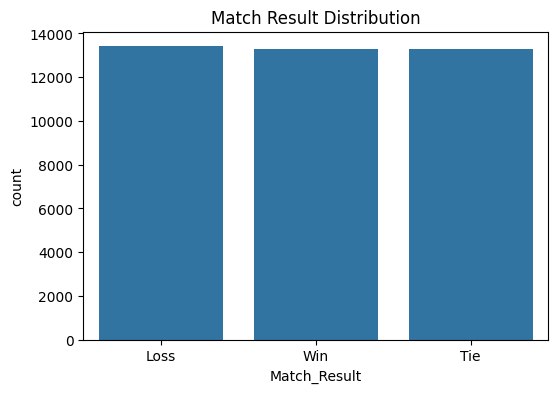

In [12]:
# Target class distribution
print(df['Match_Result'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Match_Result')
plt.title("Match Result Distribution")
plt.show()

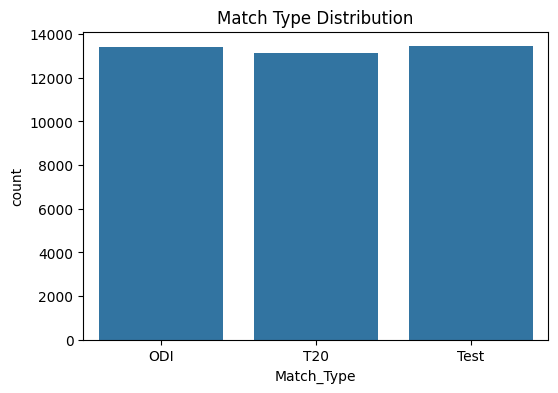

In [13]:
# Match type distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Match_Type')
plt.title("Match Type Distribution")
plt.show()

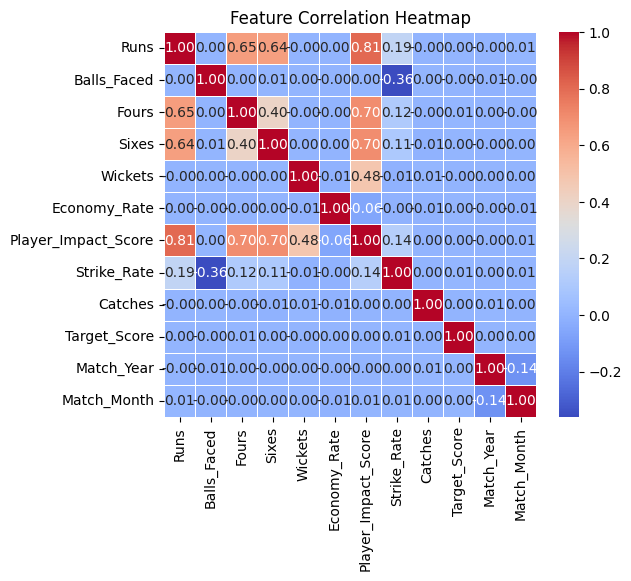

In [14]:
# Correlation among numeric features
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### 4.4 Label Encoding (Categorical Columns)

In [15]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Match_Result classes:", dict(enumerate(label_encoders['Match_Result'].classes_)))
df.head()

Match_Result classes: {0: 'Loss', 1: 'Tie', 2: 'Win'}


,Player_Name,Team,Opponent,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Match_Result,Match_Type,Player_Impact_Score,Strike_Rate,Catches,Target_Score,Match_Year,Match_Month
0,3,4,1,76,60,19,5,5,3.11,0,0,184.78,126.67,3,305,2024,6
1,5,0,3,146,73,1,10,4,6.56,0,1,171.88,200.00,1,135,2020,6
2,2,2,1,116,41,15,15,5,6.42,0,1,220.16,282.93,4,327,2024,2
3,6,7,0,147,99,12,11,0,4.78,2,1,120.94,148.48,0,287,2022,1
4,2,7,5,6,128,0,1,3,3.72,1,2,58.56,4.69,0,335,2023,6


### 4.5 Feature Scaling

In [16]:
target = 'Match_Result'
numerical_cols = df.select_dtypes(include=['number']).columns
scale_cols = [c for c in numerical_cols if c != target]

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df.head()

,Player_Name,Team,Opponent,Runs,Balls_Faced,Fours,Sixes,Wickets,Economy_Rate,Match_Result,Match_Type,Player_Impact_Score,Strike_Rate,Catches,Target_Score,Match_Year,Match_Month
0,0.428571,0.571429,0.142857,0.380,0.395973,0.38,0.151515,1.0,0.015714,0,0.0,0.516361,0.006334,0.75,0.660714,0.8,0.454545
1,0.714286,0.000000,0.428571,0.730,0.483221,0.02,0.303030,0.8,0.508571,0,0.5,0.483740,0.010000,0.25,0.053571,0.0,0.454545
2,0.285714,0.285714,0.142857,0.580,0.268456,0.30,0.454545,1.0,0.488571,0,0.5,0.605826,0.014147,1.00,0.739286,0.8,0.090909
3,0.857143,1.000000,0.000000,0.735,0.657718,0.24,0.333333,0.0,0.254286,2,0.5,0.354928,0.007424,0.00,0.596429,0.4,0.000000
4,0.285714,1.000000,0.714286,0.030,0.852349,0.00,0.030303,0.6,0.102857,1,1.0,0.197188,0.000235,0.00,0.767857,0.6,0.454545


### 4.6 Train-Test Split

In [17]:
features = df.columns[df.columns != target]
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (28000, 16)
Testing set: (12000, 16)


## 5. Fit Algorithms on Train Dataset & Evaluate One by One

### 5.1 SVM (Support Vector Machine)

In [18]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Confusion Matrix (SVM):\n", confusion_matrix(y_test, y_pred_svm))
print("\nAccuracy (SVM):", round(accuracy_score(y_test, y_pred_svm) * 100, 2), "%")
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred_svm))

Confusion Matrix (SVM):
 [[1634 1066 1299]
 [1650 1119 1309]
 [1608 1016 1299]]

Accuracy (SVM): 33.77 %

Classification Report (SVM):
               precision    recall  f1-score   support

           0       0.33      0.41      0.37      3999
           1       0.35      0.27      0.31      4078
           2       0.33      0.33      0.33      3923

    accuracy                           0.34     12000
   macro avg       0.34      0.34      0.34     12000
weighted avg       0.34      0.34      0.34     12000



### 5.2 Naive Bayes (NB)

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix (Naive Bayes):\n", confusion_matrix(y_test, y_pred_nb))
print("\nAccuracy (Naive Bayes):", round(accuracy_score(y_test, y_pred_nb) * 100, 2), "%")
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_nb))

Confusion Matrix (Naive Bayes):
 [[ 502 2260 1237]
 [ 488 2353 1237]
 [ 501 2256 1166]]

Accuracy (Naive Bayes): 33.51 %

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

           0       0.34      0.13      0.18      3999
           1       0.34      0.58      0.43      4078
           2       0.32      0.30      0.31      3923

    accuracy                           0.34     12000
   macro avg       0.33      0.33      0.31     12000
weighted avg       0.33      0.34      0.31     12000



### 5.3 K-Nearest Neighbors (KNN)

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("Confusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("\nAccuracy (KNN):", round(accuracy_score(y_test, y_pred_knn) * 100, 2), "%")
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn))

Confusion Matrix (KNN):
 [[1828 1339  832]
 [1833 1358  887]
 [1816 1303  804]]

Accuracy (KNN): 33.25 %

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.33      0.46      0.39      3999
           1       0.34      0.33      0.34      4078
           2       0.32      0.20      0.25      3923

    accuracy                           0.33     12000
   macro avg       0.33      0.33      0.32     12000
weighted avg       0.33      0.33      0.32     12000



### 5.4 Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Confusion Matrix (Decision Tree):\n", confusion_matrix(y_test, y_pred_dt))
print("\nAccuracy (Decision Tree):", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")
print("\nClassification Report (Decision Tree):\n", classification_report(y_test, y_pred_dt))

Confusion Matrix (Decision Tree):
 [[1363 1308 1328]
 [1357 1374 1347]
 [1294 1319 1310]]

Accuracy (Decision Tree): 33.73 %

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.34      0.34      0.34      3999
           1       0.34      0.34      0.34      4078
           2       0.33      0.33      0.33      3923

    accuracy                           0.34     12000
   macro avg       0.34      0.34      0.34     12000
weighted avg       0.34      0.34      0.34     12000



### 5.5 Random Forest

In [22]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Confusion Matrix (Random Forest):\n", confusion_matrix(y_test, y_pred_rf))
print("\nAccuracy (Random Forest):", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
 [[1482 1241 1276]
 [1517 1271 1290]
 [1459 1179 1285]]

Accuracy (Random Forest): 33.65 %

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.33      0.37      0.35      3999
           1       0.34      0.31      0.33      4078
           2       0.33      0.33      0.33      3923

    accuracy                           0.34     12000
   macro avg       0.34      0.34      0.34     12000
weighted avg       0.34      0.34      0.34     12000



## 6. Model Comparison (Evaluation Summary)

In [23]:
results = {
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
}

comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
comparison_df['Accuracy (%)'] = (comparison_df['Accuracy'] * 100).round(2)
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False)
comparison_df

,Model,Accuracy,Accuracy (%)
0,SVM,0.337667,33.77
3,Decision Tree,0.337250,33.72
4,Random Forest,0.336500,33.65
1,Naive Bayes,0.335083,33.51
2,KNN,0.332500,33.25


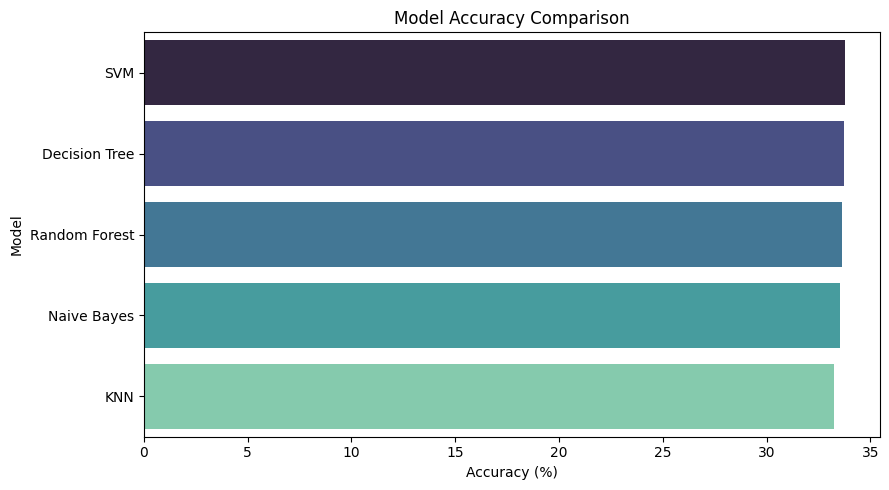

In [24]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x='Accuracy (%)', y='Model', hue='Model', palette='mako', legend=False)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.tight_layout()
plt.show()

## 7. Prediction

Best-performing model (highest accuracy) use karke test set ke pehle 10 samples ki prediction actual values ke saath compare kar rahe hain.

In [25]:
best_model_name = comparison_df.iloc[0]['Model']
model_lookup = {
    'SVM': svm_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
}
best_model = model_lookup[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)

result_table = X_test.copy()
result_table['Actual_Match_Result'] = label_encoders['Match_Result'].inverse_transform(y_test)
result_table['Predicted_Match_Result'] = label_encoders['Match_Result'].inverse_transform(y_pred_best)

result_table[['Actual_Match_Result', 'Predicted_Match_Result']].head(10)

Best Model: SVM


,Actual_Match_Result,Predicted_Match_Result
12836,Loss,Tie
10913,Loss,Loss
4214,Tie,Win
8198,Loss,Tie
31403,Tie,Tie
13917,Loss,Win
27440,Loss,Loss
11667,Loss,Win
29616,Win,Win
39864,Win,Loss


## 8. Visualizations (Matplotlib)

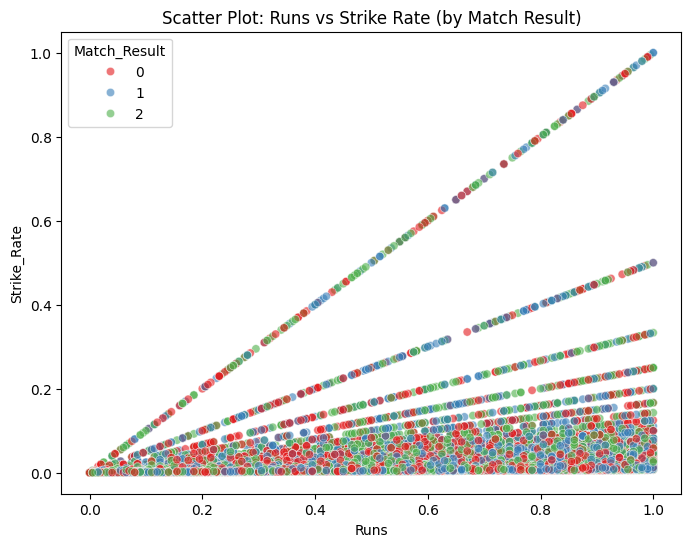

In [26]:
### Scatter Plot - Runs vs Strike Rate colored by Match Result ###
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Runs', y='Strike_Rate', hue='Match_Result', palette='Set1', alpha=0.6)
plt.title("Scatter Plot: Runs vs Strike Rate (by Match Result)")
plt.show()

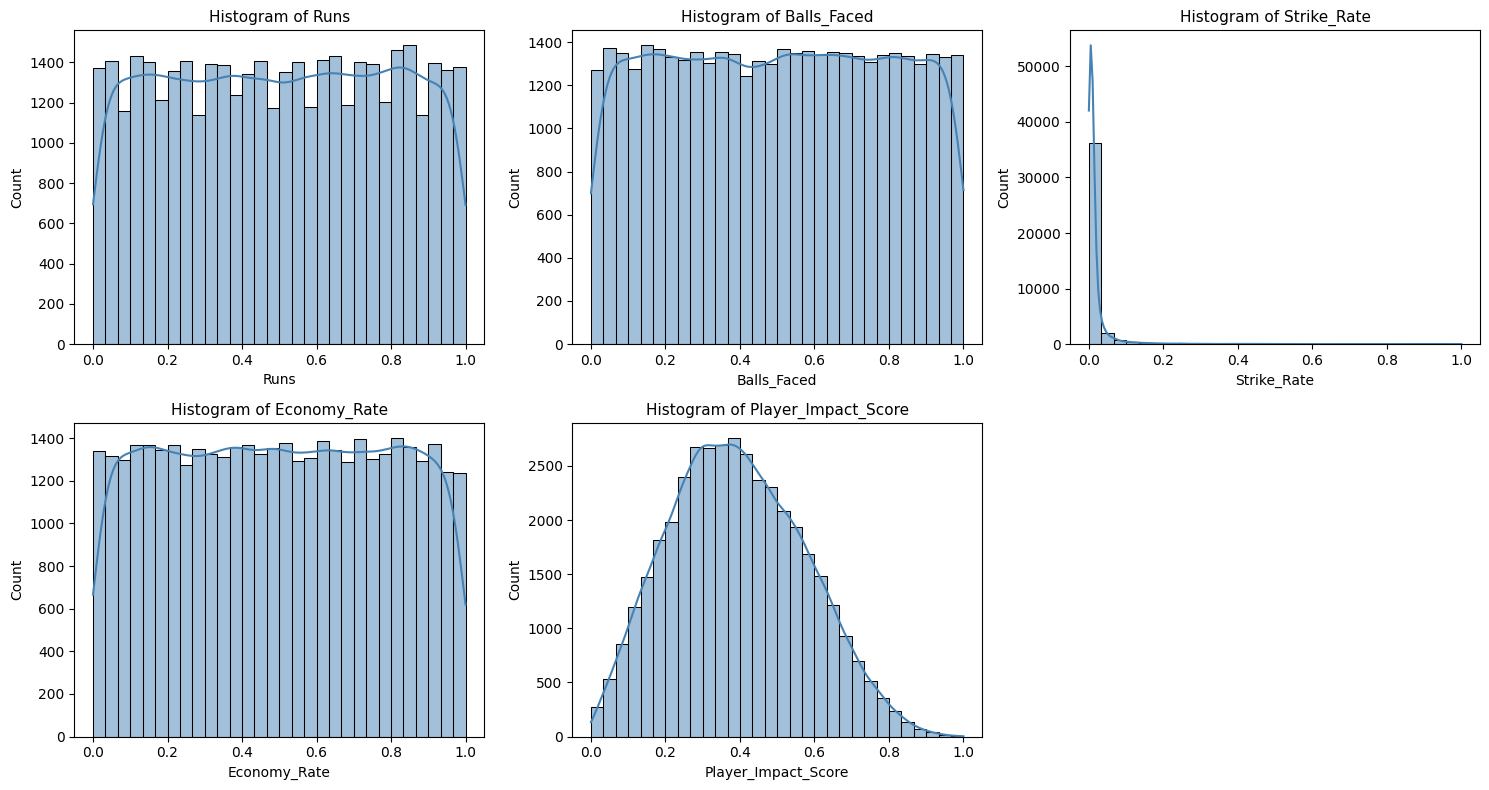

In [27]:
### Histograms of Key Numerical Attributes (Grid Layout) ###
hist_cols = ['Runs', 'Balls_Faced', 'Strike_Rate', 'Economy_Rate', 'Player_Impact_Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Histogram of {col}", fontsize=11)

axes[5].axis('off')
plt.tight_layout()
plt.show()

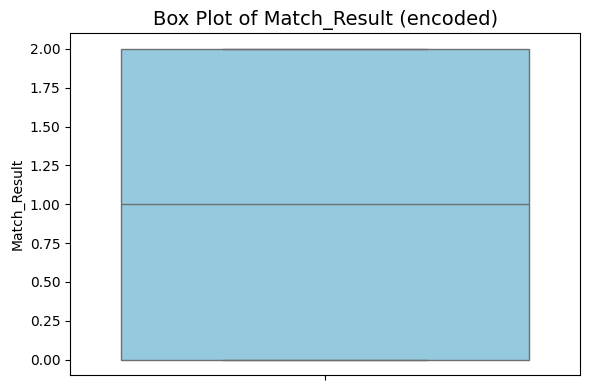

In [28]:
### Box Plot - Match_Result distribution ###
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Match_Result'], color='skyblue')
plt.title("Box Plot of Match_Result (encoded)", fontsize=14)
plt.ylabel("Match_Result")
plt.tight_layout()
plt.show()

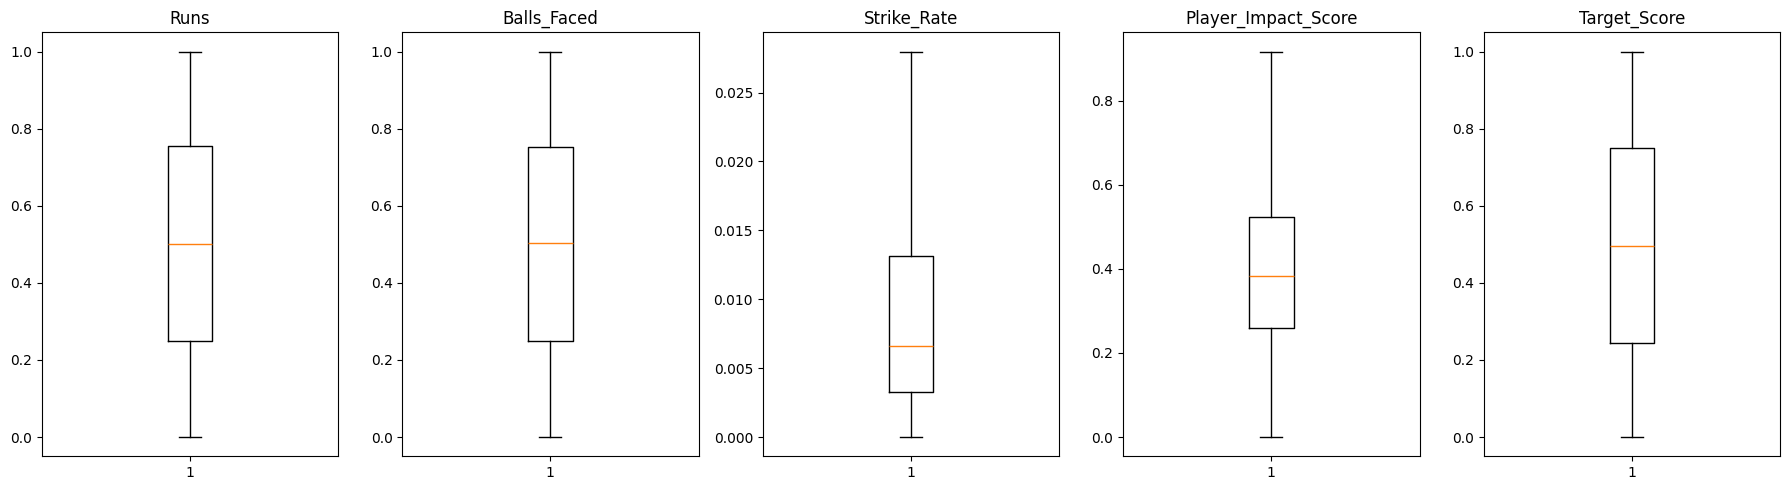

In [29]:
### Box Plots without Outliers - Key Numeric Stats ###
numerical_columns = ['Runs', 'Balls_Faced', 'Strike_Rate', 'Player_Impact_Score', 'Target_Score']
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 5))
for idx, col in enumerate(numerical_columns):
    data = df[col].dropna()
    axes[idx].boxplot(data, showfliers=False)
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

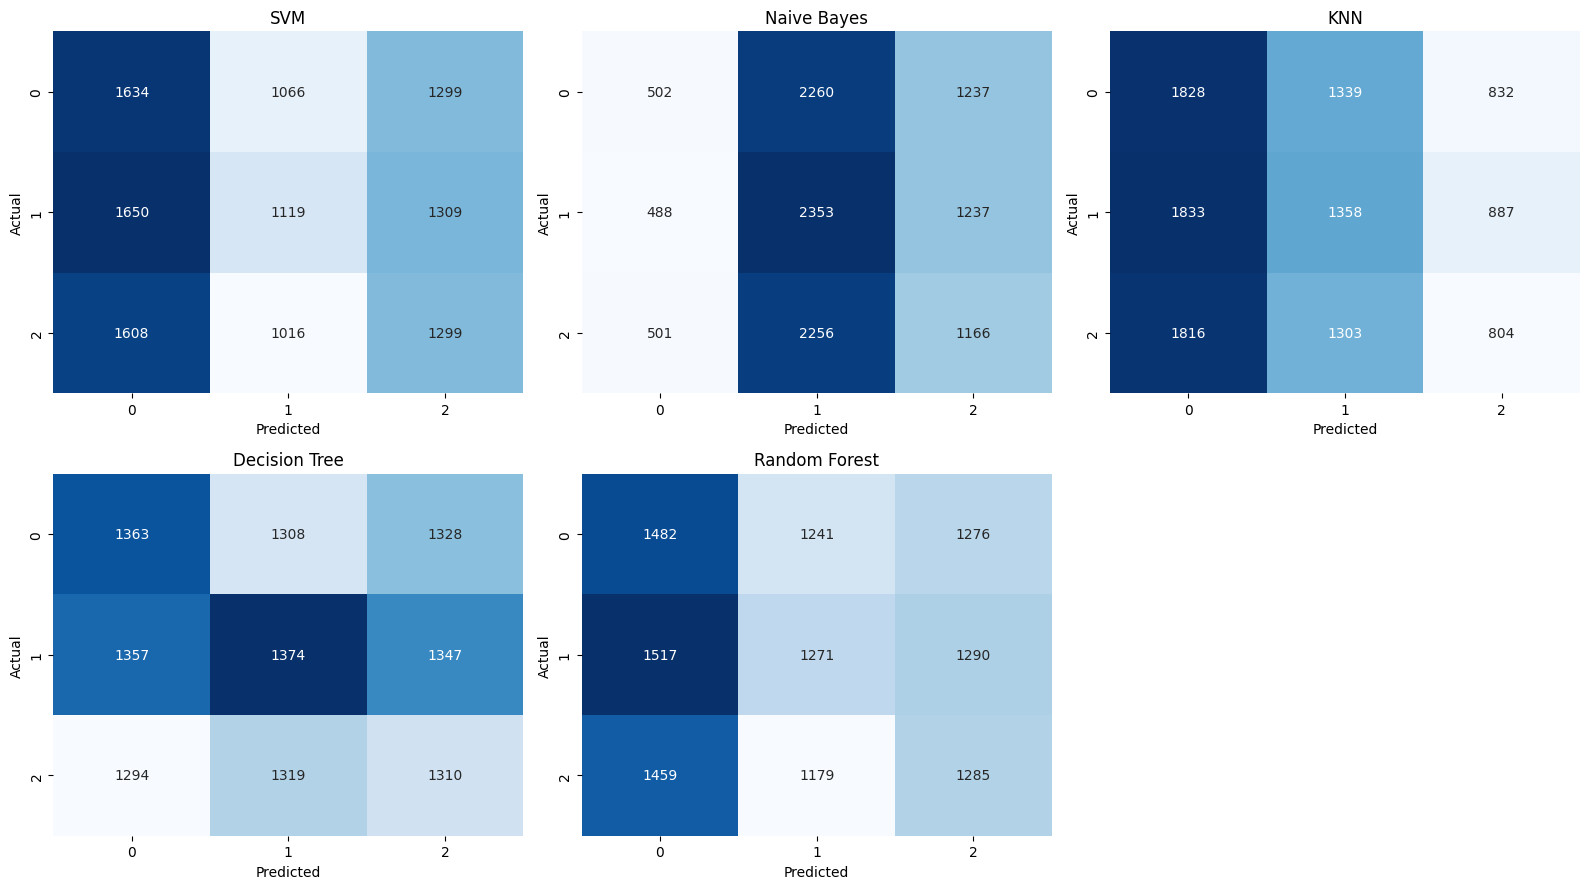

In [30]:
### Confusion Matrix Heatmaps for all models ###
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

preds = {
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
}

for i, (name, pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

axes[5].axis('off')
plt.tight_layout()
plt.show()